# Lista de Exercícios 02 — Prática com NumPy e PyTorch
**Disciplina:** Inteligência Artificial  
**Prof. Gabriel Duarte**  
**Aluna:** Alane Damasceno Moreno  

## Regressão Linear: Equação Normal, MSE e RMSE

Nesta atividade implementei regressão linear pela equação normal usando NumPy e reproduzi previsões e métricas com PyTorch. O `sklearn` é usado somente ao final, para conferência.

## 1. Preparação do ambiente

In [ ]:
!pip install torch numpy scikit-learn matplotlib pandas -q

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| numpy:", np.__version__)
print("GPU disponível:", torch.cuda.is_available())
print("Dispositivo:", device)

torch: 2.11.0+cpu | numpy: 2.0.2
GPU disponível: False
Dispositivo: cpu


## 2. Dataset escolhido — Auto MPG

Escolhi o **Auto MPG**, do UCI Machine Learning Repository. O alvo é `mpg` (milhas por galão). Utilizo seis features numéricas: `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration` e `model_year`.

Link direto: `https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data`

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

colunas = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

df = pd.read_csv(
    url,
    sep=r"\s+",
    header=None,
    names=colunas,
    na_values="?"
)

print("Formato original:", df.shape)
display(df.head())

Formato original: (398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### Tratamento dos valores faltantes

In [ ]:
print("Valores faltantes:")
display(df.isna().sum())

df = df.dropna().reset_index(drop=True)

print("Formato após a limpeza:", df.shape)
print("Amostras válidas restantes:", len(df))

Valores faltantes:


,0
mpg,0
cylinders,0
displacement,6
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0


Formato após a limpeza: (392, 8)
Amostras válidas restantes: 392


### Resposta
A quantidade de amostras válidas é mostrada acima. As linhas com valores faltantes foram removidas antes da criação de `X` e `y`.

In [ ]:
features = [
    "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year"
]

X = df[features].to_numpy(dtype=float)
y = df["mpg"].to_numpy(dtype=float)

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (392, 6)
y.shape: (392,)


# Exercício 1 — Equação Normal com NumPy

A solução fechada da regressão linear é:

\[
w^*=(X^TX)^{-1}X^Ty
\]

Também utilizarei `np.linalg.solve`, que resolve diretamente o sistema linear e tende a ser numericamente mais estável.

## 3.1 Split 80% treino / 20% teste

In [ ]:
Xtr_original, Xte_original, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Treino:", Xtr_original.shape, ytr.shape)
print("Teste:", Xte_original.shape, yte.shape)

Treino: (313, 6) (313,)
Teste: (79, 6) (79,)


## 3.2 Padronização z-score usando somente estatísticas do treino

In [ ]:
mu = Xtr_original.mean(axis=0)
sd = Xtr_original.std(axis=0)

Xtr = (Xtr_original - mu) / sd
Xte = (Xte_original - mu) / sd

display(pd.DataFrame({
    "Feature": features,
    "Média do treino": mu,
    "Desvio do treino": sd
}))

,Feature,Média do treino,Desvio do treino
0,cylinders,195.517572,103.600673
1,displacement,104.594249,38.222464
2,horsepower,2986.124601,839.789218
3,weight,15.544089,2.813359
4,acceleration,76.207668,3.624333
5,model_year,1.555911,0.805872


### Por que padronizar?
Uso as estatísticas somente do treino para evitar vazamento de informação. A padronização melhora a comparabilidade entre os coeficientes e pode ajudar no condicionamento numérico de `XᵀX`.

## 3.3 Matriz de design com coluna de 1s

In [ ]:
Xtr_design = np.hstack([np.ones((Xtr.shape[0], 1)), Xtr])
Xte_design = np.hstack([np.ones((Xte.shape[0], 1)), Xte])

print("Xtr_design:", Xtr_design.shape)
print("Xte_design:", Xte_design.shape)

Xtr_design: (313, 7)
Xte_design: (79, 7)


## 3.4 Equação normal: inversa × `np.linalg.solve`

In [ ]:
def equacao_normal_inversa(X, y):
    XtX = X.T @ X
    Xty = X.T @ y
    return np.linalg.inv(XtX) @ Xty

def equacao_normal_solve(X, y):
    XtX = X.T @ X
    Xty = X.T @ y
    return np.linalg.solve(XtX, Xty)

w_inv = equacao_normal_inversa(Xtr_design, ytr)
w = equacao_normal_solve(Xtr_design, ytr)

print("Pesos pela inversa:")
print(w_inv)
print("\nPesos por solve:")
print(w)
print("\nMaior diferença:", np.max(np.abs(w_inv - w)))

Pesos pela inversa:
[ 5.48242812  1.62057175 -0.14299876  0.17258699 -0.02113498 -0.00558775
  0.08026125]

Pesos por solve:
[ 5.48242812  1.62057175 -0.14299876  0.17258699 -0.02113498 -0.00558775
  0.08026125]

Maior diferença: 3.552713678800501e-15


### Comparação
As duas soluções devem ficar praticamente iguais. No restante do notebook utilizo `np.linalg.solve`.

## 3.5 Pesos encontrados

In [ ]:
nomes_pesos = ["intercepto"] + features
display(pd.DataFrame({"Parâmetro": nomes_pesos, "Peso": w}))

,Parâmetro,Peso
0,intercepto,5.482428
1,cylinders,1.620572
2,displacement,-0.142999
3,horsepower,0.172587
4,weight,-0.021135
5,acceleration,-0.005588
6,model_year,0.080261


## 3.6 Previsões no treino e teste

In [ ]:
def prever_numpy(X_design, pesos):
    return X_design @ pesos

yhat_tr = prever_numpy(Xtr_design, w)
yhat_te = prever_numpy(Xte_design, w)

display(pd.DataFrame({
    "Valor real": yte[:5],
    "Valor previsto": yhat_te[:5],
    "Erro": yte[:5] - yhat_te[:5]
}))

,Valor real,Valor previsto,Erro
0,4.0,3.927340,0.072660
1,4.0,4.278874,-0.278874
2,4.0,3.905219,0.094781
3,4.0,3.680462,0.319538
4,4.0,4.578538,-0.578538


## 3.7 Desafio — feature de maior peso em módulo

In [ ]:
pesos_features = w[1:]
indice_maior_peso = np.argmax(np.abs(pesos_features))
feature_mais_influente = features[indice_maior_peso]
peso_mais_influente = pesos_features[indice_maior_peso]

print("Feature de maior peso em módulo:", feature_mais_influente)
print("Peso:", peso_mais_influente)

if peso_mais_influente > 0:
    print("Sinal positivo: quando a feature cresce, o mpg previsto tende a aumentar.")
else:
    print("Sinal negativo: quando a feature cresce, o mpg previsto tende a diminuir.")

Feature de maior peso em módulo: cylinders
Peso: 1.6205717512491984
Sinal positivo: quando a feature cresce, o mpg previsto tende a aumentar.


### Interpretação
Como as features foram padronizadas, o coeficiente indica aproximadamente quanto o `mpg` previsto muda quando a feature aumenta um desvio-padrão, mantendo as demais constantes.

# Exercício 2 — MSE e RMSE

Implementei as duas métricas manualmente. O MSE fica em `mpg²`; o RMSE volta para `mpg`, por isso é mais fácil de interpretar.

## 4.1 MSE e RMSE com NumPy

In [ ]:
def mse_numpy(y_real, y_previsto):
    return np.mean((y_real - y_previsto) ** 2)

def rmse_numpy(y_real, y_previsto):
    return np.sqrt(mse_numpy(y_real, y_previsto))

mse_treino_np = mse_numpy(ytr, yhat_tr)
rmse_treino_np = rmse_numpy(ytr, yhat_tr)
mse_teste_np = mse_numpy(yte, yhat_te)
rmse_teste_np = rmse_numpy(yte, yhat_te)

display(pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MSE": [mse_treino_np, mse_teste_np],
    "RMSE": [rmse_treino_np, rmse_teste_np]
}))

,Conjunto,MSE,RMSE
0,Treino,0.259177,0.509095
1,Teste,0.318011,0.563925


## 4.2 Previsões e métricas com tensores PyTorch

In [ ]:
Xte_t = torch.tensor(Xte_design, dtype=torch.float32, device=device)
yte_t = torch.tensor(yte, dtype=torch.float32, device=device)
w_t = torch.tensor(w, dtype=torch.float32, device=device)

yhat_te_t = Xte_t @ w_t
erros_t = yte_t - yhat_te_t
mse_torch = (erros_t ** 2).mean()
rmse_torch = torch.sqrt(mse_torch)

print("MSE PyTorch:", mse_torch.item())
print("RMSE PyTorch:", rmse_torch.item())

MSE PyTorch: 0.31801125407218933
RMSE PyTorch: 0.5639248490333557


## 4.3 Igualdade NumPy × PyTorch

In [ ]:
dif_mse_np_torch = abs(mse_teste_np - mse_torch.item())
dif_rmse_np_torch = abs(rmse_teste_np - rmse_torch.item())
maior_dif_np_torch = max(dif_mse_np_torch, dif_rmse_np_torch)

print("Diferença MSE:", dif_mse_np_torch)
print("Diferença RMSE:", dif_rmse_np_torch)
print("Maior diferença:", maior_dif_np_torch)

Diferença MSE: 2.3449876429548766e-08
Diferença RMSE: 4.198236869257244e-09
Maior diferença: 2.3449876429548766e-08


### Resposta
As diferenças devem ser desprezíveis. NumPy normalmente trabalha em `float64`, enquanto os tensores desta atividade foram criados em `float32`, o que explica pequenas diferenças numéricas.

## 4.4 Conferência com scikit-learn

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

modelo_sklearn = LinearRegression()
modelo_sklearn.fit(Xtr, ytr)
yhat_sklearn = modelo_sklearn.predict(Xte)

mse_sklearn = mean_squared_error(yte, yhat_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)

display(pd.DataFrame({
    "Implementação": [
        "NumPy — equação normal",
        "PyTorch — mesmos pesos",
        "scikit-learn — conferência"
    ],
    "MSE teste": [mse_teste_np, mse_torch.item(), mse_sklearn],
    "RMSE teste": [rmse_teste_np, rmse_torch.item(), rmse_sklearn]
}))

print("Diferença MSE NumPy × sklearn:", abs(mse_teste_np - mse_sklearn))
print("Diferença RMSE NumPy × sklearn:", abs(rmse_teste_np - rmse_sklearn))

,Implementação,MSE teste,RMSE teste
0,NumPy — equação normal,0.318011,0.563925
1,PyTorch — mesmos pesos,0.318011,0.563925
2,scikit-learn — conferência,0.318011,0.563925


Diferença MSE NumPy × sklearn: 2.7755575615628914e-16
Diferença RMSE NumPy × sklearn: 2.220446049250313e-16


### Resposta
O resultado do `LinearRegression` deve ser praticamente igual ao da implementação manual, pois ambos resolvem o mesmo problema de mínimos quadrados.

## 4.5 Desafio — interpretação do RMSE

In [ ]:
print(f"RMSE do teste: {rmse_teste_np:.4f} mpg")
print(
    f"Interpretação: os erros do modelo possuem magnitude típica "
    f"de aproximadamente {rmse_teste_np:.2f} mpg no conjunto de teste."
)

RMSE do teste: 0.5639 mpg
Interpretação: os erros do modelo possuem magnitude típica de aproximadamente 0.56 mpg no conjunto de teste.


## 4.6 Desafio — sem padronização

In [ ]:
Xtr_sem_pad_design = np.hstack([np.ones((Xtr_original.shape[0], 1)), Xtr_original])
Xte_sem_pad_design = np.hstack([np.ones((Xte_original.shape[0], 1)), Xte_original])

w_sem_pad = equacao_normal_solve(Xtr_sem_pad_design, ytr)
yhat_tr_sem_pad = prever_numpy(Xtr_sem_pad_design, w_sem_pad)
yhat_te_sem_pad = prever_numpy(Xte_sem_pad_design, w_sem_pad)

mse_tr_sem = mse_numpy(ytr, yhat_tr_sem_pad)
rmse_tr_sem = rmse_numpy(ytr, yhat_tr_sem_pad)
mse_te_sem = mse_numpy(yte, yhat_te_sem_pad)
rmse_te_sem = rmse_numpy(yte, yhat_te_sem_pad)

display(pd.DataFrame({
    "Versão": ["Padronizada", "Sem padronização"],
    "MSE treino": [mse_treino_np, mse_tr_sem],
    "RMSE treino": [rmse_treino_np, rmse_tr_sem],
    "MSE teste": [mse_teste_np, mse_te_sem],
    "RMSE teste": [rmse_teste_np, rmse_te_sem]
}))

,Versão,MSE treino,RMSE treino,MSE teste,RMSE teste
0,Padronizada,0.259177,0.509095,0.318011,0.563925
1,Sem padronização,0.259177,0.509095,0.318011,0.563925


### Resposta — O que a padronização mudou?
Em uma regressão linear resolvida exatamente, a mudança de escala não deve alterar de forma relevante as previsões, portanto MSE e RMSE tendem a ficar praticamente iguais. O que muda bastante são os pesos, pois sem padronização cada coeficiente está na unidade original de sua feature. Com z-score, a comparação entre magnitudes dos pesos fica mais interpretável.

In [ ]:
display(pd.DataFrame({
    "Parâmetro": nomes_pesos,
    "Peso padronizado": w,
    "Peso sem padronização": w_sem_pad
}))

,Parâmetro,Peso padronizado,Peso sem padronização
0,intercepto,5.482428,2.280976
1,cylinders,1.620572,0.015642
2,displacement,-0.142999,-0.003741
3,horsepower,0.172587,0.000206
4,weight,-0.021135,-0.007512
5,acceleration,-0.005588,-0.001542
6,model_year,0.080261,0.099596


# Exercício 3 — Previsão concreta e análise

## 5.1 Primeira linha do teste em unidade original

In [ ]:
amostra_original = Xte_original[0].copy()
valor_real_amostra = yte[0]

display(pd.DataFrame([amostra_original], columns=features))
print("Valor real:", valor_real_amostra, "mpg")

,cylinders,displacement,horsepower,weight,acceleration,model_year
0,96.0,69.0,2189.0,18.0,72.0,2.0


Valor real: 4.0 mpg


## 5.2 Padronização da amostra e previsão

In [ ]:
amostra_pad = (amostra_original - mu) / sd
amostra_design = np.hstack([[1.0], amostra_pad])

previsao_amostra = amostra_design @ w
erro_absoluto_amostra = abs(valor_real_amostra - previsao_amostra)

print(f"Valor real: {valor_real_amostra:.4f} mpg")
print(f"Valor previsto: {previsao_amostra:.4f} mpg")
print(f"Erro absoluto: {erro_absoluto_amostra:.4f} mpg")

Valor real: 4.0000 mpg
Valor previsto: 3.9273 mpg
Erro absoluto: 0.0727 mpg


### Resposta — Preciso despadronizar a previsão?
Não. Somente as features foram padronizadas; o alvo `y` permaneceu em `mpg`. Logo, a previsão já sai na unidade original. Se o alvo também fosse padronizado, o RMSE inicialmente sairia na escala padronizada e seria necessário aplicar a transformação inversa para interpretá-lo em `mpg`.

## 5.3 Erro da amostra × RMSE do teste

In [ ]:
print(f"Erro absoluto da amostra: {erro_absoluto_amostra:.4f} mpg")
print(f"RMSE do teste: {rmse_teste_np:.4f} mpg")

if erro_absoluto_amostra > rmse_teste_np:
    print("A amostra errou mais que o erro típico do modelo.")
elif erro_absoluto_amostra < rmse_teste_np:
    print("A amostra errou menos que o erro típico do modelo.")
else:
    print("O erro da amostra foi igual ao RMSE.")

Erro absoluto da amostra: 0.0727 mpg
RMSE do teste: 0.5639 mpg
A amostra errou menos que o erro típico do modelo.


## 5.4 Desafio — aumentar a feature mais influente em 1 desvio-padrão

In [ ]:
amostra_media_pad = np.zeros(len(features))
amostra_media_design = np.hstack([[1.0], amostra_media_pad])
previsao_media = amostra_media_design @ w

amostra_alterada_pad = amostra_media_pad.copy()
amostra_alterada_pad[indice_maior_peso] = 1.0
amostra_alterada_design = np.hstack([[1.0], amostra_alterada_pad])
previsao_alterada = amostra_alterada_design @ w

mudanca = previsao_alterada - previsao_media

print("Feature:", feature_mais_influente)
print(f"Peso: {peso_mais_influente:.4f}")
print(f"Previsão na média: {previsao_media:.4f} mpg")
print(f"Previsão após +1 desvio-padrão: {previsao_alterada:.4f} mpg")
print(f"Mudança na previsão: {mudanca:.4f} mpg")

Feature: cylinders
Peso: 1.6206
Previsão na média: 5.4824 mpg
Previsão após +1 desvio-padrão: 7.1030 mpg
Mudança na previsão: 1.6206 mpg


### Resposta
A mudança deve coincidir com o peso da feature, pois o modelo é linear. Aumentar uma variável padronizada em exatamente uma unidade, mantendo as demais constantes, altera a previsão pelo valor do seu coeficiente.

## 6. Visualização dos valores reais × previstos

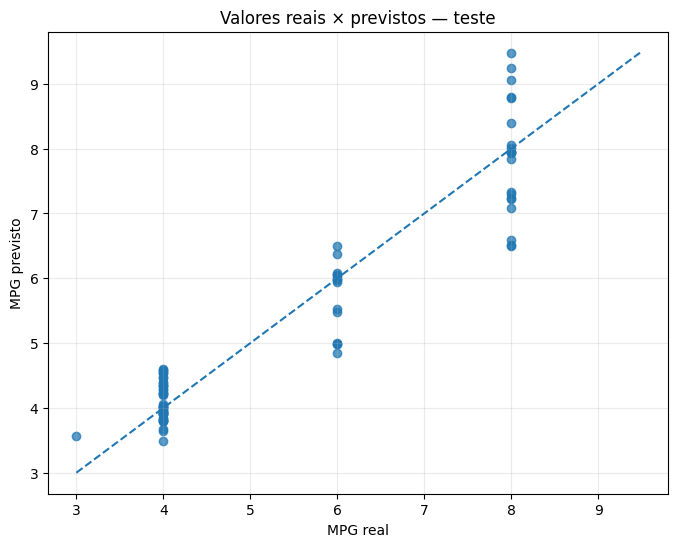

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(yte, yhat_te, alpha=0.75)

lim_min = min(yte.min(), yhat_te.min())
lim_max = max(yte.max(), yhat_te.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")

plt.xlabel("MPG real")
plt.ylabel("MPG previsto")
plt.title("Valores reais × previstos — teste")
plt.grid(alpha=0.25)
plt.show()

# 7. Resumo final

In [ ]:
resumo = pd.DataFrame({
    "Item": [
        "Dataset", "Amostras válidas", "Número de features",
        "MSE treino", "RMSE treino", "MSE teste", "RMSE teste",
        "Feature mais influente", "Peso da feature"
    ],
    "Resultado": [
        "Auto MPG — UCI", len(df), len(features),
        f"{mse_treino_np:.6f}", f"{rmse_treino_np:.6f}",
        f"{mse_teste_np:.6f}", f"{rmse_teste_np:.6f}",
        feature_mais_influente, f"{peso_mais_influente:.6f}"
    ]
})
display(resumo)
print("Link do dataset:", url)

,Item,Resultado
0,Dataset,Auto MPG — UCI
1,Amostras válidas,392
2,Número de features,6
3,MSE treino,0.259177
4,RMSE treino,0.509095
5,MSE teste,0.318011
6,RMSE teste,0.563925
7,Feature mais influente,cylinders
8,Peso da feature,1.620572


Link do dataset: https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data


# 8. Comparativo final

## 8.1 MSE e RMSE deram praticamente os mesmos valores entre NumPy, tensores e sklearn? Qual a maior diferença?

In [ ]:
diferencas = {
    "MSE NumPy × PyTorch": abs(mse_teste_np - mse_torch.item()),
    "RMSE NumPy × PyTorch": abs(rmse_teste_np - rmse_torch.item()),
    "MSE NumPy × sklearn": abs(mse_teste_np - mse_sklearn),
    "RMSE NumPy × sklearn": abs(rmse_teste_np - rmse_sklearn)
}

for nome, valor in diferencas.items():
    print(f"{nome}: {valor:.12f}")

maior_nome = max(diferencas, key=diferencas.get)
maior_valor = diferencas[maior_nome]

print(f"\nMaior diferença: {maior_valor:.12f} ({maior_nome})")
print(
    "\nResposta: Sim. Os resultados são praticamente iguais. "
    "As pequenas diferenças são compatíveis com precisão numérica, "
    "principalmente pelo uso de float32 nos tensores."
)

MSE NumPy × PyTorch: 0.000000023450
RMSE NumPy × PyTorch: 0.000000004198
MSE NumPy × sklearn: 0.000000000000
RMSE NumPy × sklearn: 0.000000000000

Maior diferença: 0.000000023450 (MSE NumPy × PyTorch)

Resposta: Sim. Os resultados são praticamente iguais. As pequenas diferenças são compatíveis com precisão numérica, principalmente pelo uso de float32 nos tensores.


## 8.2 O RMSE é maior ou menor que o MSE? Por quê?

Não existe uma regra de que o valor numérico do RMSE seja sempre maior ou sempre menor que o MSE. Como `RMSE = √MSE`, se o MSE for maior que 1, sua raiz será numericamente menor; se estiver entre 0 e 1, a raiz será numericamente maior.

O ponto mais importante é a **unidade**: neste problema, o MSE está em `mpg²`, enquanto o RMSE está em `mpg`. Por isso o RMSE é mais intuitivo para interpretar o erro típico do modelo.

## 8.3 Qual feature mais influencia o alvo? O sinal do peso faz sentido?

In [ ]:
print(
    f"A feature de maior peso em módulo foi '{feature_mais_influente}', "
    f"com coeficiente {peso_mais_influente:.4f}."
)

if peso_mais_influente > 0:
    print(
        "O sinal é positivo: aumentar essa feature está associado a "
        "um aumento do mpg previsto, mantendo as demais constantes."
    )
else:
    print(
        "O sinal é negativo: aumentar essa feature está associado a "
        "uma redução do mpg previsto, mantendo as demais constantes."
    )

print(
    f"Como os dados foram padronizados, uma variação de +1 desvio-padrão "
    f"nessa feature altera a previsão em aproximadamente "
    f"{peso_mais_influente:.4f} mpg."
)

A feature de maior peso em módulo foi 'cylinders', com coeficiente 1.6206.
O sinal é positivo: aumentar essa feature está associado a um aumento do mpg previsto, mantendo as demais constantes.
Como os dados foram padronizados, uma variação de +1 desvio-padrão nessa feature altera a previsão em aproximadamente 1.6206 mpg.


# 9. Conclusão

Nesta atividade implementei a regressão linear pela equação normal com NumPy, sem utilizar um modelo pronto durante o ajuste. Também implementei manualmente MSE e RMSE e reproduzi as previsões e métricas com PyTorch.

A conferência com `LinearRegression` permite verificar que a implementação manual encontra praticamente a mesma solução. O experimento sem padronização mostra que a escala das features altera principalmente os coeficientes e sua interpretação, enquanto as previsões permanecem essencialmente equivalentes quando o sistema é resolvido adequadamente.

Por fim, a previsão concreta e a análise do peso de maior módulo ajudaram a interpretar o modelo na unidade original do problema, `mpg`.

# 10. Checklist de entrega

- [x] Dataset de regressão do UCI
- [x] Tratamento de valores faltantes
- [x] Split 80/20 com `random_state=42`
- [x] Padronização usando somente treino
- [x] Coluna de 1s para intercepto
- [x] Equação normal com NumPy
- [x] Comparação inversa × `np.linalg.solve`
- [x] Previsões treino/teste
- [x] Cinco primeiras previsões
- [x] Interpretação dos pesos
- [x] MSE e RMSE com NumPy
- [x] MSE e RMSE com PyTorch
- [x] Igualdade NumPy × tensor
- [x] Conferência com sklearn
- [x] Desafio sem padronização
- [x] Previsão concreta
- [x] Comparação com RMSE
- [x] Feature mais influente
- [x] Comparativo final respondido
- [x] Resumo final com dataset, link, MSE e RMSE